# Titanic Classification problem

### The objective:
- Using the titanic dataset to build a model that predicts if a passenger survived or not.
- Train with the trained dataset, and predict with the test dataset.
- Compare predicted results with the ground truth dataset.

In [336]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [337]:
# import the dataset
df_test = pd.read_csv('titanic_test.csv')
df_train = pd.read_csv('titanic_train.csv')


### Data understanding

In [338]:
#checking the first 5 rows
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [339]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [340]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [341]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [342]:

df_test.shape

(418, 11)

In [343]:
df_train.shape

(891, 12)

- There are 12 columns for train data, and 11 columns for test data due to absence of Survived column.
- passengerId 
- Survived: This is our labeled variable
- Pclass: Cabin class in order of priority (1,2,3)
- Name of each passengers
- Sex, and age  (piority groups)
- SibSp (siblings or spouse), Parch(parent or children) indicate family on board
- Ticket number
- Fare 
- Cabin (where the passengers stayed)
- Embarked: deck level

In [344]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [345]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


- All features are in their right datatype, although there are missing values in the age, cabin and embarked columns

In [346]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


In [347]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


- From the statistical summary, there are extreme fare (likely paid by the rich passenger in higher class), which are likely to skew the data to the right. The minium value is also zero, futher investigation is needed to see if these cases are real.

- The age column for the test data is slightly left skewed, but for the train data is moderately distributed


In [348]:
# checking for null values
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [349]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [350]:
df_test.Embarked.unique()

<StringArray>
['Q', 'S', 'C']
Length: 3, dtype: str

-  Test data: There are 86 missing value in age column and 1 missing value in fare, 327 for cabin column.
- Train data: There 177 missing values in age column, 687 in cabin, and 2 in embarked column

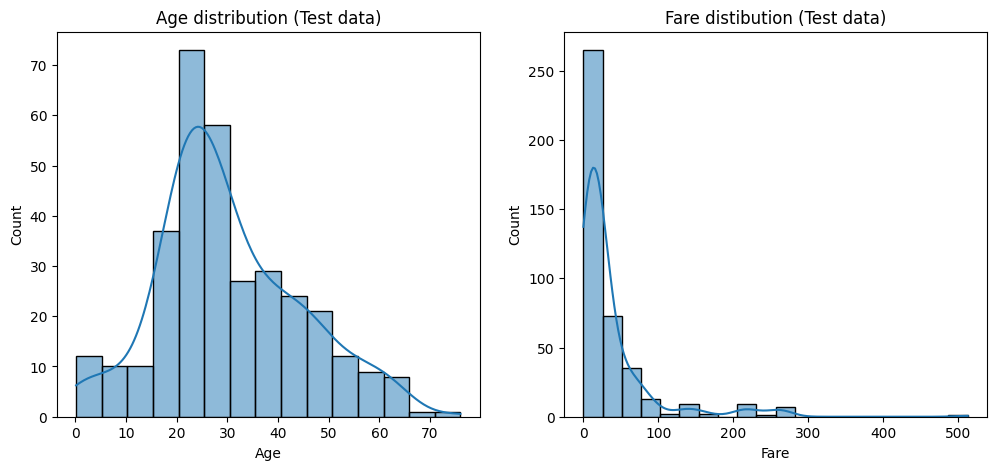

In [351]:
#visualising the distribution
plt.figure(figsize=(12,5))

#annual income
plt.subplot(1,2,1)
sns.histplot(df_test['Age'], kde=True)
plt.title('Age distribution (Test data)')

#spending score
plt.subplot(1,2,2)
sns.histplot(df_test['Fare'], kde=True, bins = 20)
plt.title('Fare distibution (Test data)')
plt.show()

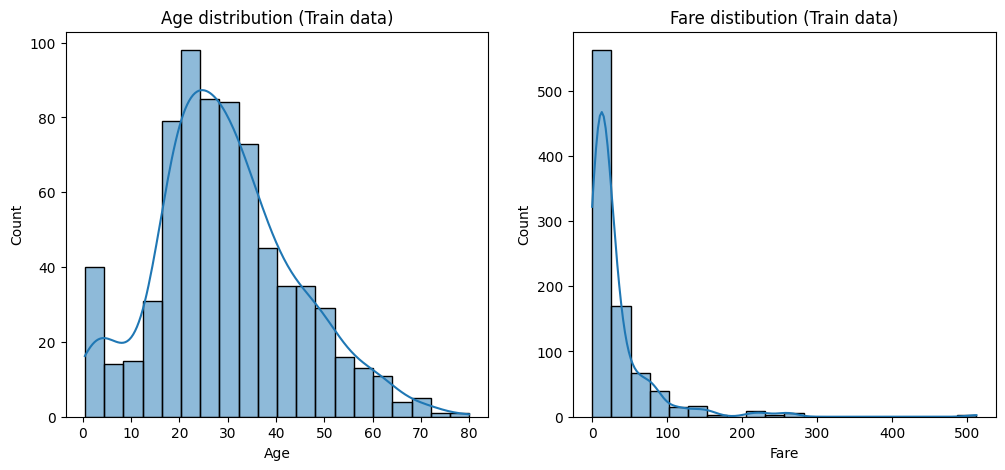

In [352]:
#visualising the distribution
plt.figure(figsize=(12,5))

#annual income
plt.subplot(1,2,1)
sns.histplot(df_train['Age'], kde=True)
plt.title('Age distribution (Train data)')


#spending score
plt.subplot(1,2,2)
sns.histplot(df_train['Fare'], kde=True, bins = 20)
plt.title('Fare distibution (Train data)')
plt.show()

- From the above, it is clear that the age is moderatly distributed and the typical age group is around 15-35, while the Fare is skewed to the right due to some extreme fare price.



In [353]:
df_test.groupby('Pclass')['Fare'].agg(['mean', 'min', 'max'])


,mean,min,max
Pclass,,,
1,94.280297,0.0000,512.3292
2,22.202104,9.6875,73.5000
3,12.459678,3.1708,69.5500


In [354]:
df_train.groupby('Pclass')['Fare'].agg(['mean', 'min', 'max'])

,mean,min,max
Pclass,,,
1,84.154687,0.0,512.3292
2,20.662183,0.0,73.5000
3,13.675550,0.0,69.5500


- The grouping above shows that the PClass-Fare distribution are logical. However, the min value of zero in Pclass 1 could br acpunting for ship officers, and employee with high class access on board. The extreme values are also coming from wealthy passengers in Pclass 1, therefore they are valid informations.

#### Handling missing values

- Fare columns will be filled  with median (median is used because they are not sensitive to outliers)
- Age column would be filled with a grouped median, instead of filling missing Age with a single value, age column will be filled based on similar people (same class and sex) to preserve pattern in data.
- Cabin column will be dropped due to high missingness, although useful. Could be transformed into another feature for better interpretability.
- Embarked column will be filled with mode value



- **NB** To avoid data leakage, missing values of the test data set will be filled with statistical values computed from the train dataset

In [355]:
#computing age group using the train dataset only
grouped_median = df_train.groupby(['Pclass', 'Sex'])['Age'].median()
grouped_median

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [356]:
# function to fill missing value in age column using grouped age 
def fill_age(row):
    if pd.isnull(row['Age']):
        return grouped_median.loc[(row['Pclass'], row['Sex'])]
    return row['Age']

# To the train data
df_train['Age'] = df_train.apply(fill_age, axis=1)

# To the test data
df_test['Age'] = df_test.apply(fill_age, axis=1)

In [357]:
# Compute from train ONLY
fare_median = df_train['Fare'].median()
embarked_mode = df_train['Embarked'].mode()[0]

# To the missing fields
df_test['Fare'] = df_test['Fare'].fillna(fare_median)

df_train['Embarked'] = df_train['Embarked'].fillna(embarked_mode)

In [358]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [359]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [360]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.112424,13.304424,0.42,21.5000,26.0000,36.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


- Now we have clean data for the modelling

#### Visualising the correlation map

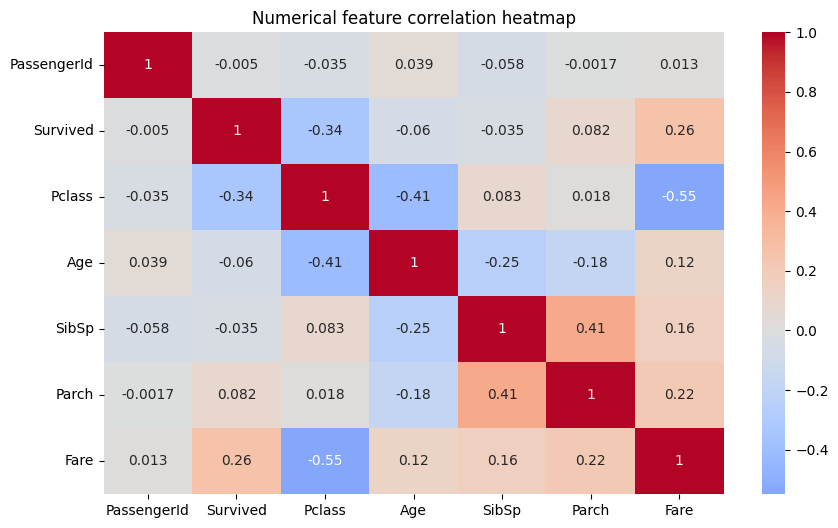

In [361]:
plt.figure(figsize=(10,6))
numeric_col = df_train.select_dtypes(include=[np.number]).columns
#plot
sns.heatmap(df_train[numeric_col].corr(), annot=True, cmap='coolwarm', center = 0)
plt.title('Numerical feature correlation heatmap')
plt.show()

- There are more of strong negative correlation that positive correlation between features. Furthermore,  the linear relationship between the label and other features is minimal. Logistic regression could be used as baseline model but another model which dis not depenedent on label-feature linearity (such as random forest classifier) should be further employed.

## Data preparation for modelling

#### Categorical variable encoding

In [362]:
# Encoding the sex column, safe to do this becuase it is pre-defined
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

# Encoding the Embarking column using one-hot encoding
df_train = pd.get_dummies(df_train, columns=['Embarked'], drop_first=True)

df_test = pd.get_dummies(df_test, columns=['Embarked'], drop_first=True)

# Align both dataset's column
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)
df_test = df_test.drop(columns='Survived')

In [363]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    int64  
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked_Q   418 non-null    bool   
 11  Embarked_S   418 non-null    bool   
dtypes: bool(2), float64(2), int64(5), str(3)
memory usage: 33.6 KB


### Feature engineering

- since Cabin column has lots of missing value, we could create a feature named `HasCabin` from it.

In [364]:
df_train['HasCabin'] = df_train['Cabin'].notnull().astype(int)
df_test['HasCabin'] = df_test['Cabin'].notnull().astype(int)

In [365]:
df_train['HasCabin'].unique()

array([0, 1])

#### Feature selection for modeling

In [366]:
df_test.columns.to_list()

['PassengerId',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked_Q',
 'Embarked_S',
 'HasCabin']

In [367]:
#train
X_train = df_train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived', 'Cabin'])
y_train= df_train['Survived']

#test
X_test = df_test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [368]:
#Check the selected features
print('=' * 30)
print('Train data:')
print('=' * 30)
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('\n')
print('=' * 30)
print('Test data:')
print('=' * 30)
print('X_test:', X_test.shape)

Train data:
X_train: (891, 9)
y_train: (891,)


Test data:
X_test: (418, 9)


#### Dataset splitting

In [369]:
train_X, valid_X, train_y, valid_y = train_test_split(X_train, y_train, test_size=0.2, random_state=234,stratify=y_train)


#confirming the splitted data

print(f'The size of X_train: {train_X.shape} \nThe size of X_test: {valid_X.shape}')
print('')
# check the value count
print(f'The value count of each class in the y_train set:\n', train_y.value_counts())
print('')
print(f'The value count of each class in the y_test set:\n', valid_y.value_counts())

The size of X_train: (712, 9) 
The size of X_test: (179, 9)

The value count of each class in the y_train set:
 Survived
0    439
1    273
Name: count, dtype: int64

The value count of each class in the y_test set:
 Survived
0    110
1     69
Name: count, dtype: int64


- Since I want to use logistic regression as my baseline model, the features needed to be scaled

#### Data scaling

In [370]:
scaler = StandardScaler()

train_X_scaled = scaler.fit_transform(train_X)
valid_X_scaled = scaler.transform(valid_X)
X_test_scaled = scaler.transform(X_test) #test data

#convert the scaled array to dataframe
#x_train_scaled_df = pd.DataFrame(train_X_scaled, columns = train_X.columns) 
#valid_X_scaled_df = pd.DataFrame(valid_X_scaled, columns = valid_X.columns)

   


# Logistic regression model

### Model training


In [371]:
model_LR = LogisticRegression(random_state=234, max_iter=200)
model_LR.fit(train_X_scaled, train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",234
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

### Model prediction

In [372]:
prediction_LR = model_LR.predict(valid_X_scaled)
print(f'Logistic regression prediction (Top 10): \n{prediction_LR[:10]}\n\n \
    Actual values (Top 10): \n{valid_y.values[:10]}\
      ')
#prediction_LR = pd.Series(prediction_LR, index=y_test.index)

Logistic regression prediction (Top 10): 
[1 1 1 0 0 0 0 1 0 0]

     Actual values (Top 10): 
[0 1 1 0 0 0 0 1 0 0]      


#### Model evaluation

In [373]:
accuracy = accuracy_score(valid_y, prediction_LR)
print(f'The accuracy of the model is {accuracy:.2f}, in percentage is {(accuracy*100):.2f}% ')

The accuracy of the model is 0.84, in percentage is 83.80% 


In [374]:
#Detailed classification model report
c_report = classification_report(valid_y, prediction_LR,  target_names=["Did Not Survive", "Survived"])
print('=' * 50)
print ('Classfication detailed report')
print('=' * 50)
print(c_report)

Classfication detailed report
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.92      0.87       110
       Survived       0.84      0.71      0.77        69

       accuracy                           0.84       179
      macro avg       0.84      0.81      0.82       179
   weighted avg       0.84      0.84      0.83       179



- The logistic regression model achieved an accuracy of ~84%, indicating strong overall performance on the validation dataset. It performed particularly well in identifying non-survivors, with a recall of 0.92, meaning most passengers who did not survive were correctly classified. For survivors, the model achieved a precision of 0.84 and a recall of 0.71, indicating that while predictions for survival were generally accurate, some survivors were missed. This is likely attributed to class rate imbalance meaning, the non-survival rate are more compared to survival-rate, hence, non-survival rate dominates the model.

## Confusion matrix and visualisation

In [375]:
conf_matrix_LR = confusion_matrix(valid_y, prediction_LR)
print(f'The confusion matrix is:\n {conf_matrix_LR}')

The confusion matrix is:
 [[101   9]
 [ 20  49]]


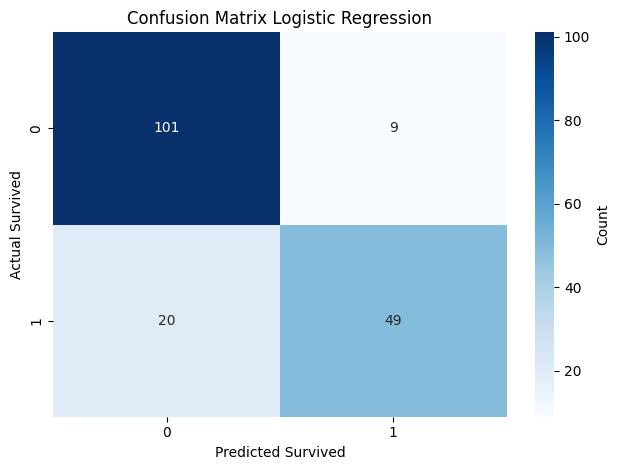

In [376]:
#visualising the confusion matrix
plt.Figure(figsize=(7,5))
Survived = sorted(valid_y.unique())
sns.heatmap(conf_matrix_LR, annot=True, fmt='d', cmap='Blues', 
            xticklabels=Survived,
            yticklabels=Survived,
            cbar_kws={'label': 'Count'})
plt.ylabel('Actual Survived')
plt.xlabel('Predicted Survived')
plt.title(f'Confusion Matrix Logistic Regression')
plt.tight_layout()
plt.show()

- The confusion matrix further solidify the hypothesis that the model didnt do well in predicting the survivor.

In [377]:

importance = model_LR.coef_[0]
importance

feature_importance = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': importance
})

feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()

feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

print(feature_importance)

      Feature  Importance  Abs_Importance
1         Sex    1.272429        1.272429
0      Pclass   -0.912998        0.912998
2         Age   -0.552137        0.552137
3       SibSp   -0.253980        0.253980
8    HasCabin    0.221891        0.221891
4       Parch   -0.179856        0.179856
7  Embarked_S   -0.135865        0.135865
6  Embarked_Q   -0.067837        0.067837
5        Fare    0.042938        0.042938


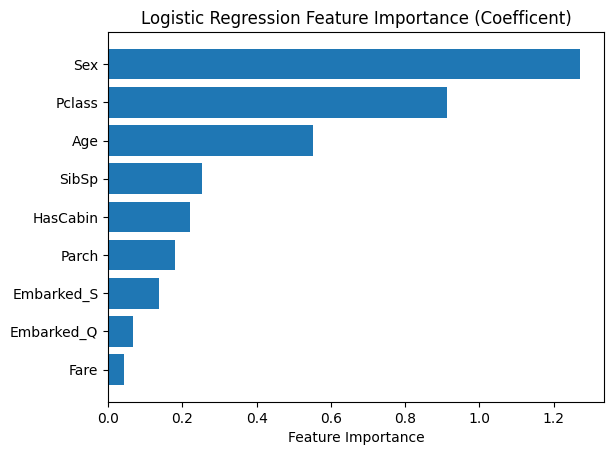

In [378]:
feature_importance = feature_importance.sort_values(by='Abs_Importance')

plt.barh(feature_importance['Feature'], feature_importance['Abs_Importance'])
plt.xlabel("Feature Importance")
plt.title("Logistic Regression Feature Importance (Coefficent)")
plt.show()

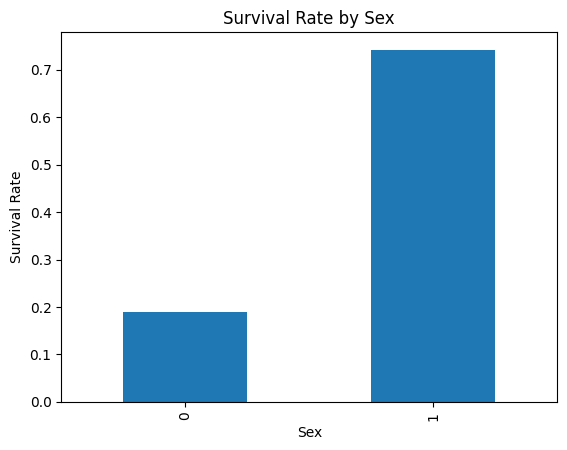

In [379]:
df_train.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")
plt.show()

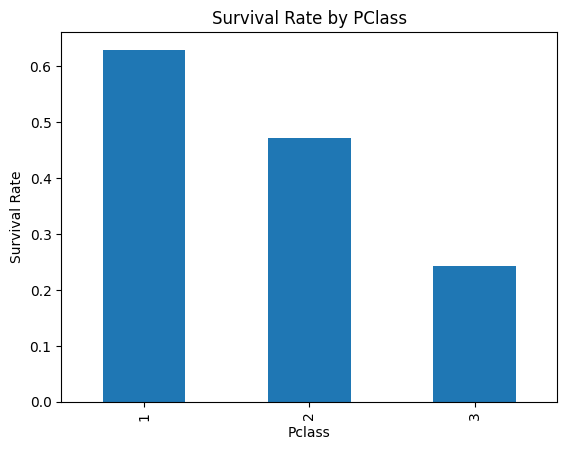

In [380]:
df_train.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.ylabel("Survival Rate")
plt.title("Survival Rate by PClass")
plt.show()

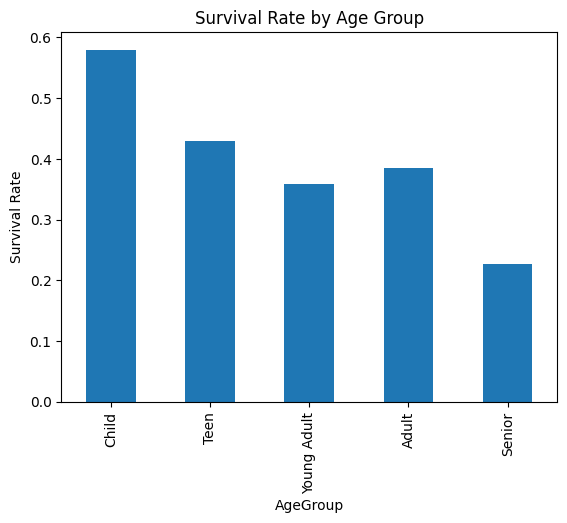

In [381]:
import matplotlib.pyplot as plt

# create age groups
df_train['AgeGroup'] = pd.cut(
    df_train['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

# plot survival rate
df_train.groupby('AgeGroup')['Survived'].mean().plot(kind='bar')

plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group")
plt.show()

- The logistic regression model identifies Sex as the most influential factor, with females(1) significantly more likely to survive. Passenger class and age also play major roles, with higher-class (1) and younger passengers (child and Teen) having better survival chances. The negative effect indicates that higher class number and older age reduce survival chances.

- Features such as having a cabin, SibSp and Parch (family size), and embarkation point have moderate effects, while fare and certain embarkation variables contribute only minimally. The model highlights socioeconomic status and gender as the primary drivers of survival outcomes. It is indicates positive/negative relationships.

#### Prediction using unseen dataset `df_test`

- Final prediction

In [382]:
y_test_pred = model_LR.predict(X_test_scaled)

In [318]:

final_prediction = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_test_pred
})

final_prediction["Survived_Label"] = final_prediction["Survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})


final_prediction.to_csv("final_titanic_prediction_LR.csv", index=False)

In [403]:
final_prediction.head(10)

,PassengerId,Survived,Survived_Label
0,892,0,Did Not Survive
1,893,0,Did Not Survive
2,894,0,Did Not Survive
3,895,0,Did Not Survive
4,896,1,Survived
5,897,0,Did Not Survive
6,898,1,Survived
7,899,0,Did Not Survive
8,900,1,Survived
9,901,0,Did Not Survive


#### Compare the predicted with the titanic dataset (ground truth)

In [396]:
sub_lr = pd.read_csv('final_titanic_prediction_LR.csv')
sub_df = pd.read_csv('Titanic_dataset.csv')
 
comparison = pd.merge(
    sub_lr[['PassengerId', 'Survived']],
    sub_df[['PassengerId', 'Survived']],
    on='PassengerId',
    suffixes=('_LR', '_True')
)


In [397]:
accuracy = (comparison['Survived_LR'] == comparison['Survived_True']).mean()
print("Match rate:", accuracy)

print(classification_report(
    comparison['Survived_True'],
    comparison['Survived_LR']
))

Match rate: 0.9186602870813397
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       266
           1       0.88      0.90      0.89       152

    accuracy                           0.92       418
   macro avg       0.91      0.91      0.91       418
weighted avg       0.92      0.92      0.92       418



In [400]:
comparison.head(20)

,PassengerId,Survived_LR,Survived_True
0,892,0,0
1,893,0,1
2,894,0,0
3,895,0,0
4,896,1,1
5,897,0,0
6,898,1,1
7,899,0,0
8,900,1,1
9,901,0,0


The model evaluation shows a very strong performance with the ground truth, achieving a match rate (accuracy) of approximately 91.9% on the unseen dataset. The model performs particularly well in predicting non-survivors, with high precision and recall, while also maintaining strong performance in identifying survivors, with balanced precision (0.88) and recall (0.90). The F1-scores for both classes (0.94 for non-survival and 0.89 for survival) indicate a well-balanced model with good predictive consistency across classes. 

### Saving the logistic regression model

In [321]:
import joblib
#model_filename = 'trained_iris_model.pkl'

# save the best model
joblib.dump(model_LR, 'trained_titanic_LR_model.pkl')
print(f'Model saved as trained_titanic_LR_model.pkl')

# save the scalar too
joblib.dump(scaler, 'titanic_LR_scaler.pkl' )
print(f'Scalar saved as titanic_LR_scaler.pkl')

Model saved as trained_titanic_LR_model.pkl
Scalar saved as titanic_LR_scaler.pkl


# Random forest model


In [322]:
#Train the model 
# there is no need to use scaled value here.
model_RF = RandomForestClassifier(n_estimators=100, random_state=42)

model_RF.fit(train_X, train_y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [323]:
# validate the model
prediction_RF = model_RF.predict(valid_X) #validate
print(f'Random forest prediction (Top 10): \n{prediction_RF[:10]}\n\n \
    Actual values (Top 10): \n{valid_y.values[:10]}\
      ')



Random forest prediction (Top 10): 
[0 1 1 0 1 1 0 1 0 0]

     Actual values (Top 10): 
[0 1 1 0 0 0 0 1 0 0]      


In [324]:
# Evaluate the model
print("Accuracy:", accuracy_score(valid_y, prediction_RF))
print(classification_report(valid_y, prediction_RF))


Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



- The Random Forest model achieved an accuracy of approximately ~82%, which is very close to the Logistic Regression model. It also performs well in identifying non-survivors, with a recall of 0.87, indicating strong detection of passengers who did not survive (class-rate imbalance in the dataset). For survivors, it achieves a precision of 0.78 and a recall of 0.72.

- Logistic Regression slightly outperforms Random Forest, this indicates that the Titanic dataset is simple and structured.

The confusion matrix is:
 [[96 14]
 [19 50]]


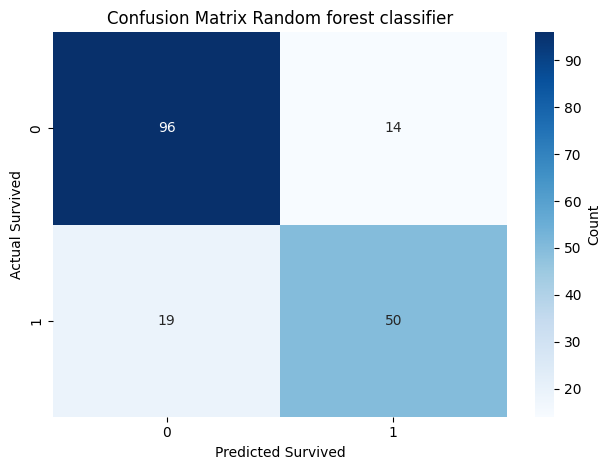

In [325]:
conf_matrix_RF = confusion_matrix(valid_y, prediction_RF)
print(f'The confusion matrix is:\n {conf_matrix_RF}')

#visualising the confusion matrix
plt.Figure(figsize=(7,5))
sns.heatmap(conf_matrix_RF, annot=True, fmt='d', cmap='Blues', 
            xticklabels=Survived,
            yticklabels=Survived,
            cbar_kws={'label': 'Count'})
plt.ylabel('Actual Survived')
plt.xlabel('Predicted Survived')
plt.title(f'Confusion Matrix Random forest classifier')
plt.tight_layout()
plt.show()

- The non-survival rate here reduced abit, while the survival rate improved abit. This is likely becuase the dataset is simple enough, hence, a complex model wont make it better. Maybe, some random forest parameter tuning could help.

In [326]:
#feature importance
importances = model_RF.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)


      Feature  Importance
5        Fare    0.251733
2         Age    0.247847
1         Sex    0.245090
0      Pclass    0.091547
3       SibSp    0.045612
8    HasCabin    0.044755
4       Parch    0.038158
7  Embarked_S    0.027205
6  Embarked_Q    0.008053


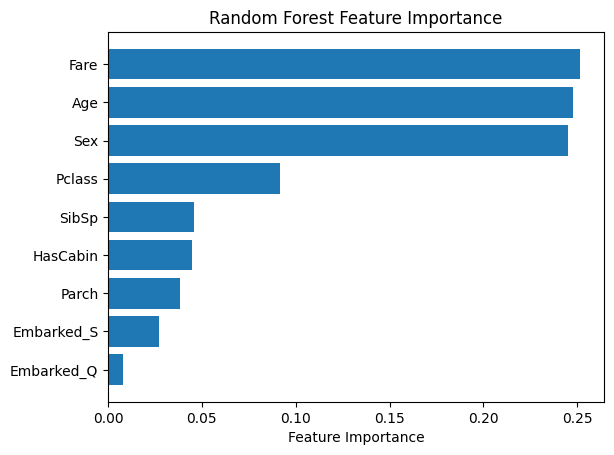

In [327]:
feature_importance = feature_importance.sort_values(by='Importance')

plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

- The top features in random forest model are Fare, Age, and Sex, with fairly similar importance values. Unlike Logistic regression, RF distributes importance more evenly across features. Pclass still matters, but less than in Logistic regression. This means that captures nonlinear relationships, so variables like Fare and Age become more influential.

- Random Forest spreads importance across multiple features (especially Age, Fare, and sex), while Logistic Regression relies more heavily on dominant linear predictors such as Sex and Pclass.

### Random forest final prediction with unseen data


In [328]:
y_pred_RF = model_RF.predict(X_test)


In [329]:
final_pred_RF = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_pred_RF
})

final_pred_RF["Survived_Label"] = final_pred_RF["Survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})

final_pred_RF.to_csv("final_titanic_prediction_RF.csv", index=False)

In [402]:
final_pred_RF.head(10)

,PassengerId,Survived,Survived_Label
0,892,0,Did Not Survive
1,893,0,Did Not Survive
2,894,0,Did Not Survive
3,895,1,Survived
4,896,0,Did Not Survive
5,897,0,Did Not Survive
6,898,0,Did Not Survive
7,899,0,Did Not Survive
8,900,1,Survived
9,901,0,Did Not Survive


 ### Comparison linear regression prediction with the original titanic dataset (ground truth)


In [394]:
sub_rf = pd.read_csv('final_titanic_prediction_RF.csv')
 
comparison = pd.merge(
    sub_rf[['PassengerId', 'Survived']],
    sub_df[['PassengerId', 'Survived']],
    on='PassengerId',
    suffixes=('_RF', '_True')
)

accuracy = (comparison['Survived_RF'] == comparison['Survived_True']).mean()
print("Match rate:", accuracy)

print(classification_report(
    comparison['Survived_True'],
    comparison['Survived_RF']
))



Match rate: 0.8133971291866029
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       266
           1       0.74      0.74      0.74       152

    accuracy                           0.81       418
   macro avg       0.80      0.80      0.80       418
weighted avg       0.81      0.81      0.81       418



In [401]:
comparison.head(20)

,PassengerId,Survived_LR,Survived_True
0,892,0,0
1,893,0,1
2,894,0,0
3,895,0,0
4,896,1,1
5,897,0,0
6,898,1,1
7,899,0,0
8,900,1,1
9,901,0,0


- The Random Forest model shows moderate performance against the ground truth data, achieving an accuracy of about 81.3% on the unseen dataset. It performs well in predicting non-survivors, with balanced precision and recall (both 0.85), but is less effective for survivors, where precision and recall drop to 0.74. Th RF model is moderately consistent but slightly biased toward the majority class, making it weaker at detecting survival compared to Logistic Regression.

- Hyperparameter tuning could make it better

#### Saving random forest model

In [332]:
import joblib
#model_filename = 'trained_iris_model.pkl'

# save the best model
joblib.dump(model_RF, 'trained_titanic_RF_model.pkl')
print(f'Model saved as trained_titanic_RF_model.pkl')




Model saved as trained_titanic_RF_model.pkl


### In conclusion, both models indicates Fare, sex, PClass, and age as the strongest factors for survival. Although, the models struggle more with survivors, due to distribution bias towards 0 (non-survival rate)

### Recommendation: Parameter tuning for the random forest model for better performance